# Continue Training ResNet50 10-class – Waste Classification

Notebook này dùng để **train tiếp model ResNet50 10-class từ checkpoint cũ** trên dataset mới đã map đủ 10 lớp.

- Dataset input bắt buộc có đủ `splits/train`, `splits/val`, `splits/test`.
- Mỗi split phải có đủ 10 folder class.
- Model giữ nguyên `ResNet50(weights=None)` và `Linear(..., 10)`.
- Mục tiêu là cải thiện `Battery` và `Cardboard` nhưng vẫn đánh giá đầy đủ 10 lớp và 4 ngăn.


## Fix note

Đã sửa lỗi cell order: bỏ train loop cũ bị lặp, đưa test evaluation lên trước confusion matrix, và giữ W&B/history theo epoch 51 trở đi.


## Kaggle GPU note

Nếu dùng **Latest Container Image** với **GPU P100**, PyTorch mới có thể báo lỗi không hỗ trợ `sm_60`. Cách an toàn nhất là đổi Accelerator sang **T4** hoặc dùng container/PyTorch cũ tương thích P100. Lỗi `ReduceLROnPlateau(verbose=True)` đã được sửa trong notebook này.


In [1]:
from pathlib import Path

class CFG:
    # SỬA 2 DÒNG NÀY TRÊN KAGGLE
    data_root = "/kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits"
    resume_ckpt_path = "/kaggle/input/models/nguynlonglb/resnet508-6/keras/default/1/best_model.pth"

    # Optional: history cũ để nối epoch/log/curve. Để "" nếu không có.
    prev_history_csv = "/kaggle/input/models/nguynlonglb/resnet508-6/keras/default/1/training_history.csv"

    output_dir = "/kaggle/working/outputs_resnet50_continue_10class_mapped"

    epochs = 12
    batch_size = 48
    num_workers = 2
    image_size = 224

    lr = 3e-5
    weight_decay = 5e-4
    use_amp = True
    grad_clip_norm = 1.0

    # "fc_only", "layer4_fc", "all"
    fine_tune_mode = "layer4_fc"

    loss_type = "focal"       # "ce" hoặc "focal"
    focal_gamma = 1.5
    label_smoothing = 0.05
    use_class_weights = True

    use_weighted_sampler = True
    sampler_power = 0.5

    scheduler_factor = 0.5
    scheduler_patience = 3
    min_lr = 1e-6
    early_stopping_patience = 6

    use_wandb = True
    wandb_project = "waste-classification"
    wandb_run_name = "resnet50_continue_10class_mapped"
    wandb_run_id = ""  # để "" để tạo run mới, an toàn nhất
    wandb_log_previous_history = True  # log lại history cũ vào run mới để W&B curve nối epoch 1..N

    seed = 42

CLASS_NAMES = [
    "Battery", "Biological", "Cardboard", "Clothes", "E_Waste",
    "Glass", "Metal", "Other", "Paper", "Plastic"
]

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

BIN4_MAP = {
    "Battery": "Hazardous",
    "E_Waste": "Hazardous",
    "Biological": "Organic",
    "Cardboard": "Recyclable",
    "Glass": "Recyclable",
    "Metal": "Recyclable",
    "Paper": "Recyclable",
    "Plastic": "Recyclable",
    "Clothes": "Other",
    "Other": "Other",
}
BIN4_NAMES = ["Hazardous", "Organic", "Recyclable", "Other"]
BIN4_TO_IDX = {c: i for i, c in enumerate(BIN4_NAMES)}

print("Data root:", CFG.data_root)
print("Resume checkpoint:", CFG.resume_ckpt_path)
print("Output dir:", CFG.output_dir)


Data root: /kaggle/input/datasets/nguynlonglb/pbl5-racthai-dut/splits
Resume checkpoint: /kaggle/input/models/nguynlonglb/resnet508-6/keras/default/1/best_model.pth
Output dir: /kaggle/working/outputs_resnet50_continue_10class_mapped


In [2]:
import os, json, time, random, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

OUT = Path(CFG.output_dir)
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
CKPT_DIR = OUT / "checkpoints"
LOG_DIR = OUT / "logs"

for p in [OUT, FIG_DIR, TAB_DIR, CKPT_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

with open(LOG_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump({k: v for k, v in CFG.__dict__.items() if not k.startswith("__") and not callable(v)}, f, indent=2, ensure_ascii=False)

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)


Device: cuda
GPU: Tesla T4
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [3]:
# =========================
# W&B SETUP
# =========================

wandb = None

if CFG.use_wandb:
    try:
        import os
        import wandb

        # Kaggle Secrets:
        # Add-ons / Secrets -> Add Secret
        # Label: WANDB_API_KEY
        # Value: your W&B API key
        try:
            from kaggle_secrets import UserSecretsClient
            user_secrets = UserSecretsClient()
            secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
            os.environ["WANDB_API_KEY"] = secret_value_0
            wandb.login(key=secret_value_0)
            print("W&B login OK from Kaggle Secret: WANDB_API_KEY")
        except Exception as e:
            print("WARNING: Cannot read WANDB_API_KEY from Kaggle Secrets.")
            print(e)
            if os.environ.get("WANDB_API_KEY"):
                wandb.login(key=os.environ["WANDB_API_KEY"])
                print("W&B login OK from environment variable.")
            else:
                raise RuntimeError(
                    "WANDB_API_KEY is missing. Add Kaggle Secret WANDB_API_KEY "
                    "or set CFG.use_wandb=False."
                )

        init_kwargs = dict(
            project=CFG.wandb_project,
            name=CFG.wandb_run_name,
            config={k: v for k, v in CFG.__dict__.items() if not k.startswith("__") and not callable(v)},
        )

        # Khuyến nghị để rỗng để tạo run mới, tránh lỗi step khi resume.
        if CFG.wandb_run_id:
            init_kwargs["id"] = CFG.wandb_run_id
            init_kwargs["resume"] = "allow"
        else:
            init_kwargs["resume"] = None

        wandb.init(**init_kwargs)
        print("W&B enabled:", wandb.run.name)

    except Exception as e:
        print("WARNING: W&B init failed. Continue without W&B.")
        print(e)
        wandb = None
else:
    print("W&B disabled.")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 102230357 (102230357-udn-com-co) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login OK from Kaggle Secret: WANDB_API_KEY


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260609_114528-kmm21ae0
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run resnet50_continue_10class_mapped
wandb: ⭐️ View project at https://wandb.ai/102230357-udn-com-co/waste-classification
wandb: 🚀 View run at https://wandb.ai/102230357-udn-com-co/waste-classification/runs/kmm21ae0


W&B enabled: resnet50_continue_10class_mapped


In [4]:
data_root = Path(CFG.data_root)
assert data_root.exists(), f"data_root không tồn tại: {data_root}"

for split in ["train", "val", "test"]:
    split_dir = data_root / split
    assert split_dir.exists(), f"Thiếu folder: {split_dir}"

    existing_classes = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    print(split, existing_classes)

    missing = [c for c in CLASS_NAMES if c not in existing_classes]
    extra = [c for c in existing_classes if c not in CLASS_NAMES]

    assert not missing, f"{split} thiếu class: {missing}"
    if extra:
        print(f"WARNING: {split} có extra folder:", extra)

print("OK: dataset có đủ 10 class trong train/val/test")


train ['Battery', 'Biological', 'Cardboard', 'Clothes', 'E_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
val ['Battery', 'Biological', 'Cardboard', 'Clothes', 'E_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
test ['Battery', 'Biological', 'Cardboard', 'Clothes', 'E_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']
OK: dataset có đủ 10 class trong train/val/test


In [5]:
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(CFG.image_size, scale=(0.75, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

eval_tfms = transforms.Compose([
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(data_root / "train", transform=train_tfms)
val_ds = datasets.ImageFolder(data_root / "val", transform=eval_tfms)
test_ds = datasets.ImageFolder(data_root / "test", transform=eval_tfms)

print("ImageFolder class_to_idx:", train_ds.class_to_idx)
assert train_ds.class_to_idx == CLASS_TO_IDX, "class_to_idx không khớp CLASS_NAMES cố định"
assert val_ds.class_to_idx == CLASS_TO_IDX
assert test_ds.class_to_idx == CLASS_TO_IDX

def count_dataset(ds, name):
    labels = [y for _, y in ds.samples]
    counts = Counter(labels)
    rows = []
    for idx, cls in IDX_TO_CLASS.items():
        rows.append({"split": name, "class_name": cls, "count": counts.get(idx, 0)})
    return pd.DataFrame(rows)

dist_df = pd.concat([
    count_dataset(train_ds, "train"),
    count_dataset(val_ds, "val"),
    count_dataset(test_ds, "test"),
], ignore_index=True)

dist_pivot = dist_df.pivot(index="class_name", columns="split", values="count").fillna(0).astype(int)
display(dist_pivot)
dist_df.to_csv(TAB_DIR / "class_distribution_by_split.csv", index=False)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))


ImageFolder class_to_idx: {'Battery': 0, 'Biological': 1, 'Cardboard': 2, 'Clothes': 3, 'E_Waste': 4, 'Glass': 5, 'Metal': 6, 'Other': 7, 'Paper': 8, 'Plastic': 9}


split,test,train,val
class_name,,,
Battery,767,3571,765
Biological,635,2956,633
Cardboard,1308,6098,1306
Clothes,800,3726,798
E_Waste,794,3698,792
Glass,765,3565,764
Metal,799,3726,798
Other,1646,7675,1644
Paper,819,3818,818


Train: 42655 Val: 9137 Test: 9153


In [6]:
train_targets = np.array([y for _, y in train_ds.samples], dtype=np.int64)
class_counts = np.bincount(train_targets, minlength=len(CLASS_NAMES))

print("Train class counts:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"{cls:12s}: {class_counts[i]}")

weights = class_counts.sum() / (len(CLASS_NAMES) * np.maximum(class_counts, 1))
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)

if CFG.use_class_weights:
    class_weights_for_loss = class_weights
else:
    class_weights_for_loss = None

print("Class weights:", class_weights.detach().cpu().numpy())

if CFG.use_weighted_sampler:
    sample_weights = (1.0 / np.maximum(class_counts[train_targets], 1)) ** CFG.sampler_power
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_ds, batch_size=CFG.batch_size, shuffle=shuffle_train, sampler=sampler,
    num_workers=CFG.num_workers, pin_memory=True,
    persistent_workers=(CFG.num_workers > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers, pin_memory=True,
    persistent_workers=(CFG.num_workers > 0),
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers, pin_memory=True,
    persistent_workers=(CFG.num_workers > 0),
)

print("Loaders ready")


Train class counts:
Battery     : 3571
Biological  : 2956
Cardboard   : 6098
Clothes     : 3726
E_Waste     : 3698
Glass       : 3565
Metal       : 3726
Other       : 7675
Paper       : 3818
Plastic     : 3822
Class weights: [1.1944833  1.4429973  0.6994916  1.1447934  1.1534613  1.1964937
 1.1447934  0.55576545 1.117208   1.1160387 ]
Loaders ready


In [7]:
def build_model(num_classes=10, dropout=0.4):
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["model_state_dict", "state_dict", "model", "net"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt

def clean_state_dict_keys(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        if nk.startswith("module."):
            nk = nk[len("module."):]
        if nk.startswith("model."):
            nk = nk[len("model."):]
        new_sd[nk] = v
    return new_sd

model = build_model(num_classes=len(CLASS_NAMES), dropout=0.4)

ckpt_path = Path(CFG.resume_ckpt_path)
assert ckpt_path.exists(), f"Checkpoint không tồn tại: {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = clean_state_dict_keys(extract_state_dict(ckpt))

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

if len(missing) > 0 or len(unexpected) > 0:
    print("WARNING: Có missing/unexpected keys. Kiểm tra checkpoint có đúng ResNet50 10-class không.")

def set_finetune_mode(model, mode):
    for p in model.parameters():
        p.requires_grad = False

    if mode == "fc_only":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "layer4_fc":
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    elif mode == "all":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown fine_tune_mode: {mode}")

set_finetune_mode(model, CFG.fine_tune_mode)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,}/{total:,} ({trainable/total:.2%})")


Missing keys: []
Unexpected keys: []
Trainable params: 14,985,226/23,528,522 (63.69%)


In [8]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none",
            label_smoothing=self.label_smoothing,
        )
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

if CFG.loss_type == "focal":
    criterion = FocalLoss(
        gamma=CFG.focal_gamma,
        weight=class_weights_for_loss,
        label_smoothing=CFG.label_smoothing,
    )
elif CFG.loss_type == "ce":
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_for_loss,
        label_smoothing=CFG.label_smoothing,
    )
else:
    raise ValueError(CFG.loss_type)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
)

# PyTorch 2.10 removed/changed the `verbose` argument in ReduceLROnPlateau.
# Use a compatibility wrapper so the notebook works across Kaggle container versions.
import inspect

scheduler_kwargs = dict(
    mode="max",
    factor=CFG.scheduler_factor,
    patience=CFG.scheduler_patience,
    min_lr=CFG.min_lr,
)

if "verbose" in inspect.signature(torch.optim.lr_scheduler.ReduceLROnPlateau).parameters:
    scheduler_kwargs["verbose"] = True

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    **scheduler_kwargs,
)

scaler = GradScaler(enabled=CFG.use_amp)

print("criterion:", criterion)
print("optimizer ready")


criterion: FocalLoss()
optimizer ready


/tmp/ipykernel_22/3628847613.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG.use_amp)


In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    all_targets = []
    all_preds = []
    all_probs = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        losses.append(loss.item() * images.size(0))
        all_targets.extend(targets.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    avg_loss = sum(losses) / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "targets": np.array(all_targets),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    losses = []
    correct = 0
    total = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=CFG.use_amp):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()

        if CFG.grad_clip_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                CFG.grad_clip_norm
            )

        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        losses.append(loss.item() * images.size(0))

    return {"loss": sum(losses) / total, "acc": correct / total}

def current_lr(optimizer):
    return optimizer.param_groups[0]["lr"]


In [10]:
# =========================
# TRAIN LOOP
# =========================

prev_history = None
history = []

# Load history cũ nếu có, để nối epoch/log/curve cho báo cáo.
if getattr(CFG, "prev_history_csv", ""):
    prev_hist_path = Path(CFG.prev_history_csv)
    if prev_hist_path.exists():
        prev_history = pd.read_csv(prev_hist_path)
        prev_history["stage"] = "previous"

        # Chuẩn hóa tên cột nếu notebook cũ có tên hơi khác.
        rename_map = {
            "train_accuracy": "train_acc",
            "val_accuracy": "val_acc",
            "valid_loss": "val_loss",
            "valid_acc": "val_acc",
            "valid_macro_f1": "val_macro_f1",
            "valid_weighted_f1": "val_weighted_f1",
        }
        prev_history = prev_history.rename(columns={k: v for k, v in rename_map.items() if k in prev_history.columns})

        if "epoch" in prev_history.columns and len(prev_history) > 0:
            start_epoch = int(prev_history["epoch"].max()) + 1
        else:
            start_epoch = 1

        print(f"Loaded previous history: {prev_hist_path}")
        print(f"Previous rows: {len(prev_history)}")
        print(f"Continue epoch numbering from: {start_epoch}")
    else:
        print(f"WARNING: prev_history_csv không tồn tại: {prev_hist_path}")
        start_epoch = 1
else:
    start_epoch = 1
    print("No previous history loaded. New history starts from epoch 1.")

# Log history cũ lên W&B run mới để curve nối liên tục.
# Chỉ nên dùng khi wandb_run_id="" hoặc đang tạo run mới.
if wandb is not None and prev_history is not None and getattr(CFG, "wandb_log_previous_history", False):
    print("Logging previous history to W&B...")
    for _, old_row in prev_history.iterrows():
        if "epoch" not in old_row or pd.isna(old_row["epoch"]):
            continue
        step = int(old_row["epoch"])
        log_dict = {}
        for key in ["train_loss", "train_acc", "val_loss", "val_acc", "val_macro_f1", "val_weighted_f1", "lr"]:
            if key in prev_history.columns and pd.notna(old_row.get(key, np.nan)):
                log_dict[key] = float(old_row[key])
        log_dict["stage"] = "previous"
        if log_dict:
            wandb.log(log_dict, step=step)
    print("Previous history logged to W&B.")


# best_val_macro_f1 dùng để chọn best checkpoint trong giai đoạn train tiếp.
# Nếu muốn chỉ lưu best mới của giai đoạn continue, giữ -1.
# Nếu muốn best phải vượt cả lịch sử cũ, tự động lấy max từ prev_history.
best_val_macro_f1 = -1.0
if prev_history is not None and "val_macro_f1" in prev_history.columns:
    old_best = pd.to_numeric(prev_history["val_macro_f1"], errors="coerce").max()
    if pd.notna(old_best):
        best_val_macro_f1 = float(old_best)
        print(f"Old best val_macro_f1 from history: {best_val_macro_f1:.4f}")

best_epoch = 0
no_improve = 0

start_time = time.time()

for local_epoch in range(1, CFG.epochs + 1):
    epoch = start_epoch + local_epoch - 1
    t0 = time.time()

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    val_metrics = evaluate(model, val_loader, criterion)

    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "local_epoch": local_epoch,
        "stage": "continue",
        "lr": current_lr(optimizer),
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "time_sec": time.time() - t0,
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} (continue {local_epoch:02d}/{CFG.epochs}) | "
        f"train_loss={row['train_loss']:.4f} train_acc={row['train_acc']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_acc={row['val_acc']:.4f} "
        f"val_macro_f1={row['val_macro_f1']:.4f} | "
        f"lr={row['lr']:.2e} | time={row['time_sec']:.1f}s"
    )

    cont_hist_df = pd.DataFrame(history)
    cont_hist_df.to_csv(TAB_DIR / "training_history_continue_only.csv", index=False)

    if prev_history is not None:
        combined_history = pd.concat([prev_history, cont_hist_df], ignore_index=True, sort=False)
    else:
        combined_history = cont_hist_df.copy()

    combined_history.to_csv(TAB_DIR / "training_history.csv", index=False)

    torch.save({
        "epoch": epoch,
        "local_epoch": local_epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_macro_f1": best_val_macro_f1,
        "class_names": CLASS_NAMES,
        "prev_history_csv": getattr(CFG, "prev_history_csv", ""),
    }, CKPT_DIR / "last_checkpoint.pth")

    improved = val_metrics["macro_f1"] > best_val_macro_f1

    if improved:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        no_improve = 0

        torch.save(model.state_dict(), CKPT_DIR / "best_model.pth")
        torch.save({
            "epoch": epoch,
            "local_epoch": local_epoch,
            "model_state_dict": model.state_dict(),
            "best_val_macro_f1": best_val_macro_f1,
            "class_names": CLASS_NAMES,
            "prev_history_csv": getattr(CFG, "prev_history_csv", ""),
        }, CKPT_DIR / "best_checkpoint.pth")

        print(f"  -> Saved best_model.pth with val_macro_f1={best_val_macro_f1:.4f}")
    else:
        no_improve += 1

    if wandb is not None:
        wandb.log(row, step=epoch)

    if no_improve >= CFG.early_stopping_patience:
        print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}, best_val_macro_f1={best_val_macro_f1:.4f}")
        break

elapsed = time.time() - start_time
print(f"Training finished. Elapsed: {elapsed/3600:.2f} hours")
print(f"Best epoch: {best_epoch}, best_val_macro_f1={best_val_macro_f1:.4f}")

torch.save(model.state_dict(), CKPT_DIR / "last_model.pth")


Loaded previous history: /kaggle/input/models/nguynlonglb/resnet508-6/keras/default/1/training_history.csv
Previous rows: 50
Continue epoch numbering from: 51
Logging previous history to W&B...
Previous history logged to W&B.
Old best val_macro_f1 from history: 0.7682


/tmp/ipykernel_22/1439095499.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


Epoch 051 (continue 01/12) | train_loss=0.2512 train_acc=0.8864 | val_loss=0.4185 val_acc=0.8296 val_macro_f1=0.8357 | lr=3.00e-05 | time=538.4s
  -> Saved best_model.pth with val_macro_f1=0.8357


/tmp/ipykernel_22/1439095499.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


Epoch 052 (continue 02/12) | train_loss=0.2172 train_acc=0.9039 | val_loss=0.3925 val_acc=0.8378 val_macro_f1=0.8421 | lr=3.00e-05 | time=473.2s
  -> Saved best_model.pth with val_macro_f1=0.8421


...

Epoch 060 (continue 10/12) | train_loss=0.1662 train_acc=0.9283 | val_loss=0.3776 val_acc=0.8549 val_macro_f1=0.8579 | lr=3.00e-05 | time=435.4s


/tmp/ipykernel_22/1439095499.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


Epoch 061 (continue 11/12) | train_loss=0.1667 train_acc=0.9273 | val_loss=0.3748 val_acc=0.8555 val_macro_f1=0.8580 | lr=3.00e-05 | time=438.2s
  -> Saved best_model.pth with val_macro_f1=0.8580


/tmp/ipykernel_22/1439095499.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.use_amp):


Epoch 062 (continue 12/12) | train_loss=0.1640 train_acc=0.9308 | val_loss=0.3797 val_acc=0.8521 val_macro_f1=0.8539 | lr=1.50e-05 | time=430.8s
Training finished. Elapsed: 1.50 hours
Best epoch: 61, best_val_macro_f1=0.8580


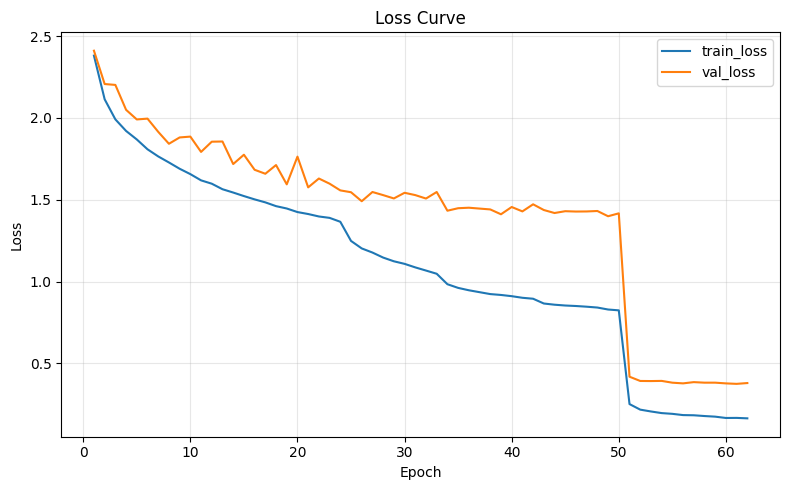

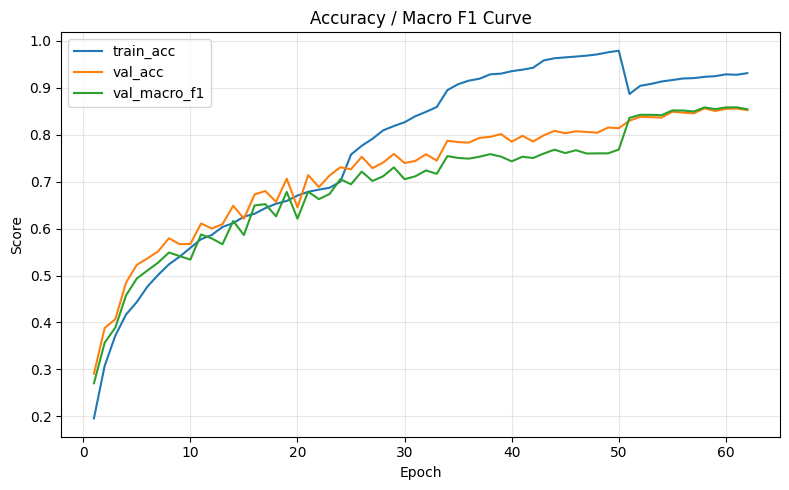

In [11]:
# =========================
# PLOT TRAINING CURVES
# =========================

hist_path = TAB_DIR / "training_history.csv"
if not hist_path.exists():
    hist_path = TAB_DIR / "training_history_continue_only.csv"

hist = pd.read_csv(hist_path)

for c in ["epoch", "train_loss", "val_loss", "train_acc", "val_acc", "val_macro_f1"]:
    if c in hist.columns:
        hist[c] = pd.to_numeric(hist[c], errors="coerce")

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.plot(hist["epoch"], hist["val_macro_f1"], label="val_macro_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Accuracy / Macro F1 Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_f1_curve.png", dpi=200)
plt.show()


In [12]:
# =========================
# LOAD BEST + TEST EVALUATION
# =========================

best_path = CKPT_DIR / "best_model.pth"
assert best_path.exists(), f"Không tìm thấy best_model.pth tại {best_path}"

best_sd = torch.load(best_path, map_location="cpu")
model.load_state_dict(best_sd, strict=True)
model = model.to(device)

test_metrics = evaluate(model, test_loader, criterion)

y_true = test_metrics["targets"]
y_pred = test_metrics["preds"]
probs = test_metrics["probs"]

print("Test loss:", test_metrics["loss"])
print("Test acc:", test_metrics["acc"])
print("Test macro_f1:", test_metrics["macro_f1"])
print("Test weighted_f1:", test_metrics["weighted_f1"])

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(TAB_DIR / "classification_report.csv")

metrics = {
    "test_loss": float(test_metrics["loss"]),
    "test_accuracy": float(test_metrics["acc"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_weighted_f1": float(test_metrics["weighted_f1"]),
    "best_epoch": int(best_epoch),
    "best_val_macro_f1": float(best_val_macro_f1),
    "num_test_samples": int(len(y_true)),
}
pd.DataFrame([metrics]).to_csv(TAB_DIR / "model_metrics.csv", index=False)

with open(LOG_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

if wandb is not None:
    wandb.log({
        "test_loss": metrics["test_loss"],
        "test_accuracy": metrics["test_accuracy"],
        "test_macro_f1": metrics["test_macro_f1"],
        "test_weighted_f1": metrics["test_weighted_f1"],
        "best_epoch": metrics["best_epoch"],
        "best_val_macro_f1": metrics["best_val_macro_f1"],
    }, step=int(metrics["best_epoch"]) + 1)

display(report_df)
display(pd.DataFrame([metrics]))


Test loss: 0.3786586482323259
Test acc: 0.8503222986998799
Test macro_f1: 0.8536949578572421
Test weighted_f1: 0.8505200011220188


,precision,recall,f1-score,support
Battery,0.912515,0.979140,0.944654,767.000000
Biological,0.884615,0.905512,0.894942,635.000000
Cardboard,0.882700,0.799694,0.839150,1308.000000
Clothes,0.950125,0.952500,0.951311,800.000000
E_Waste,0.821297,0.845088,0.833023,794.000000
Glass,0.894207,0.928105,0.910840,765.000000
Metal,0.768957,0.812265,0.790018,799.000000
Other,0.892713,0.803767,0.845908,1646.000000
Paper,0.686720,0.738706,0.711765,819.000000
Plastic,0.789714,0.842683,0.815339,820.000000


,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,best_epoch,best_val_macro_f1,num_test_samples
0,0.378659,0.850322,0.853695,0.85052,61,0.857982,9153


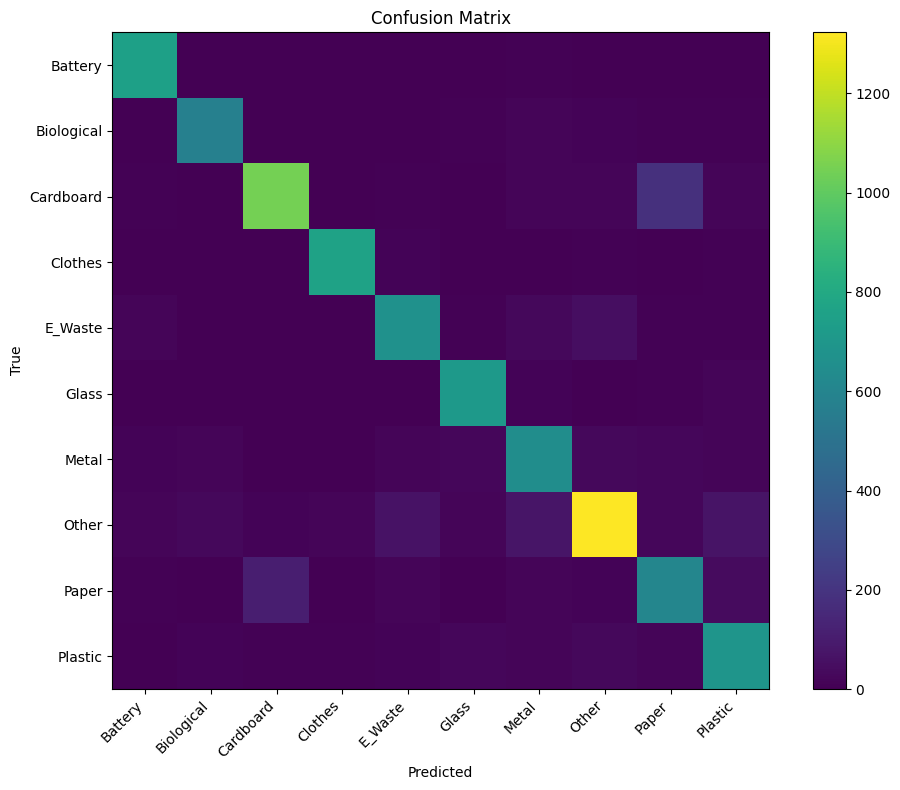

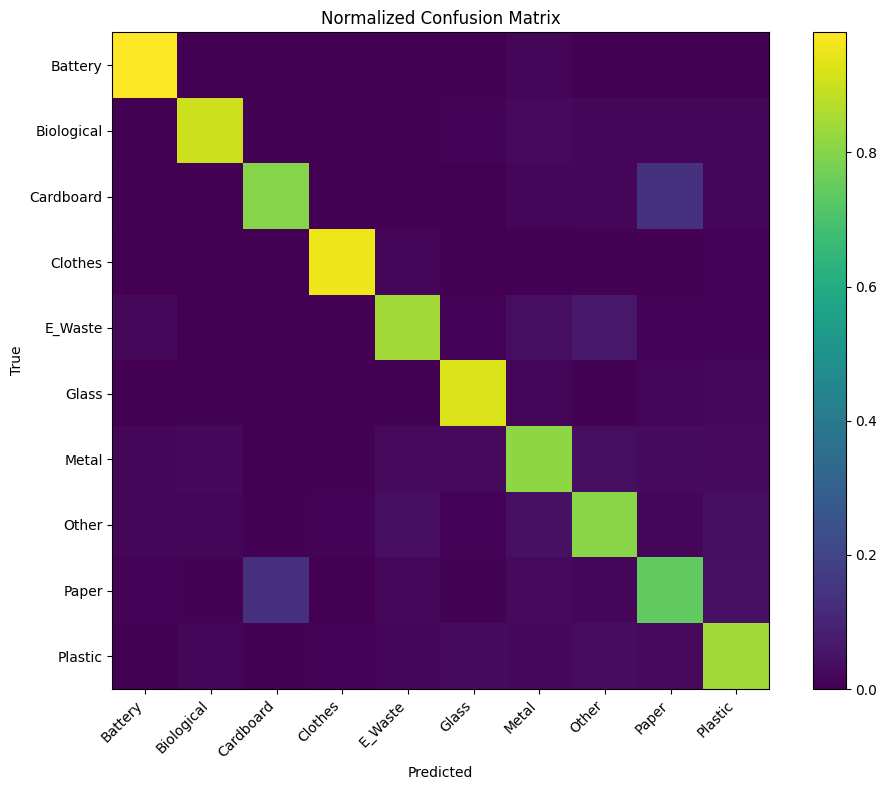

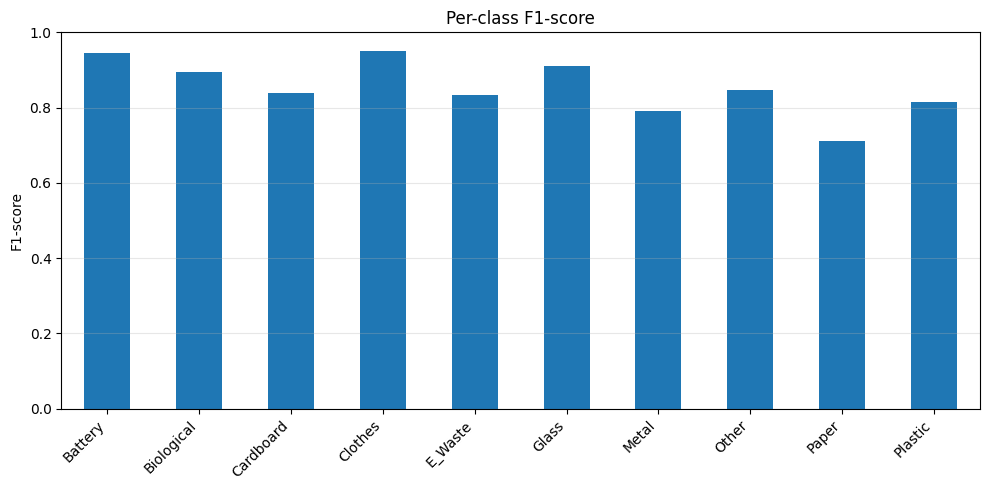

In [13]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
cm_norm = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(TAB_DIR / "confusion_matrix.csv")
pd.DataFrame(cm_norm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(TAB_DIR / "confusion_matrix_normalized.csv")

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_normalized.png", dpi=200)
plt.show()

per_class_f1 = report_df.loc[CLASS_NAMES, "f1-score"].astype(float)
plt.figure(figsize=(10, 5))
per_class_f1.plot(kind="bar")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.title("Per-class F1-score")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_f1_score.png", dpi=200)
plt.show()


In [14]:
test_paths = [p for p, _ in test_ds.samples]

pred_rows = []
for i in range(len(y_true)):
    true_idx = int(y_true[i])
    pred_idx = int(y_pred[i])
    pred_rows.append({
        "filepath": test_paths[i],
        "true_idx": true_idx,
        "true_class": IDX_TO_CLASS[true_idx],
        "pred_idx": pred_idx,
        "pred_class": IDX_TO_CLASS[pred_idx],
        "confidence": float(probs[i][pred_idx]),
        "correct": true_idx == pred_idx,
    })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(TAB_DIR / "test_predictions.csv", index=False)

print(pred_df["correct"].value_counts())
display(pred_df.head())


correct
True     7783
False    1370
Name: count, dtype: int64


,filepath,true_idx,true_class,pred_idx,pred_class,confidence,correct
0,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...,0,Battery,0,Battery,0.975785,True
1,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...,0,Battery,0,Battery,0.974248,True
2,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...,0,Battery,0,Battery,0.985210,True
3,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...,0,Battery,0,Battery,0.997634,True
4,/kaggle/input/datasets/nguynlonglb/pbl5-ractha...,0,Battery,0,Battery,0.994410,True


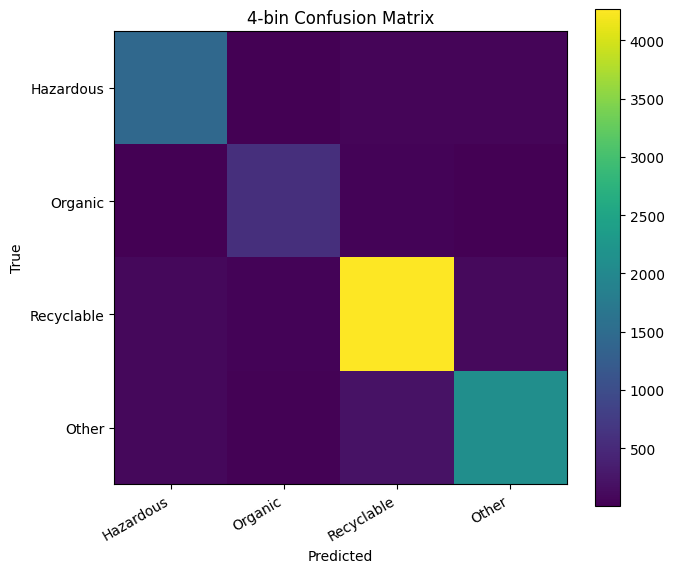

,precision,recall,f1-score,support
Hazardous,0.879268,0.923767,0.900968,1561.000000
Organic,0.884615,0.905512,0.894942,635.000000
Recyclable,0.931426,0.945467,0.938394,4511.000000
Other,0.923380,0.862224,0.891755,2446.000000
accuracy,0.916749,0.916749,0.916749,0.916749
macro avg,0.904672,0.909242,0.906515,9153.000000
weighted avg,0.917133,0.916749,0.916533,9153.000000


,bin4_accuracy,bin4_macro_f1,bin4_weighted_f1,num_test_samples
0,0.916749,0.906515,0.916533,9153


In [15]:
def class_idx_to_bin_idx(idx):
    cls = IDX_TO_CLASS[int(idx)]
    bin_name = BIN4_MAP[cls]
    return BIN4_TO_IDX[bin_name]

y_true_bin = np.array([class_idx_to_bin_idx(x) for x in y_true])
y_pred_bin = np.array([class_idx_to_bin_idx(x) for x in y_pred])

bin_report_dict = classification_report(
    y_true_bin,
    y_pred_bin,
    target_names=BIN4_NAMES,
    output_dict=True,
    zero_division=0,
)
bin_report_df = pd.DataFrame(bin_report_dict).T
bin_report_df.to_csv(TAB_DIR / "bin4_classification_report.csv")

bin_metrics = {
    "bin4_accuracy": float(accuracy_score(y_true_bin, y_pred_bin)),
    "bin4_macro_f1": float(f1_score(y_true_bin, y_pred_bin, average="macro", zero_division=0)),
    "bin4_weighted_f1": float(f1_score(y_true_bin, y_pred_bin, average="weighted", zero_division=0)),
    "num_test_samples": int(len(y_true_bin)),
}
pd.DataFrame([bin_metrics]).to_csv(TAB_DIR / "bin4_model_metrics.csv", index=False)

bin_cm = confusion_matrix(y_true_bin, y_pred_bin, labels=list(range(len(BIN4_NAMES))))
pd.DataFrame(bin_cm, index=BIN4_NAMES, columns=BIN4_NAMES).to_csv(TAB_DIR / "bin4_confusion_matrix.csv")

plt.figure(figsize=(7, 6))
plt.imshow(bin_cm)
plt.title("4-bin Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(BIN4_NAMES)), BIN4_NAMES, rotation=30, ha="right")
plt.yticks(range(len(BIN4_NAMES)), BIN4_NAMES)
plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "bin4_confusion_matrix.png", dpi=200)
plt.show()

display(bin_report_df)
display(pd.DataFrame([bin_metrics]))


In [16]:
worklog = f'''
# Worklog – Continue Training ResNet50 10-class

- Data root: `{CFG.data_root}`
- Resume checkpoint: `{CFG.resume_ckpt_path}`
- Previous history CSV: `{getattr(CFG, "prev_history_csv", "")}`
- Model: `torchvision.models.resnet50(weights=None)`
- Output head: `Dropout(0.4) + Linear(2048, 10)`
- Fine-tune mode: `{CFG.fine_tune_mode}`
- Loss: `{CFG.loss_type}`
- Class weights: `{CFG.use_class_weights}`
- WeightedRandomSampler: `{CFG.use_weighted_sampler}`
- Monitor: `val_macro_f1`
- Best epoch: `{best_epoch}`
- Best val macro F1: `{best_val_macro_f1:.4f}`
- Test accuracy: `{metrics["test_accuracy"]:.4f}`
- Test macro F1: `{metrics["test_macro_f1"]:.4f}`
- Test weighted F1: `{metrics["test_weighted_f1"]:.4f}`
- 4-bin accuracy: `{bin_metrics["bin4_accuracy"]:.4f}`

Note: Notebook này train tiếp model 10 lớp, không phải binary classifier.
'''

with open(LOG_DIR / "worklog.md", "w", encoding="utf-8") as f:
    f.write(worklog)

zip_path = shutil.make_archive(
    base_name=CFG.output_dir,
    format="zip",
    root_dir=str(OUT.parent),
    base_dir=OUT.name,
)

print("Output dir:", OUT)
print("ZIP:", zip_path)

if wandb is not None:
    wandb.finish()


wandb: uploading data; updating run metadata


Output dir: /kaggle/working/outputs_resnet50_continue_10class_mapped
ZIP: /kaggle/working/outputs_resnet50_continue_10class_mapped.zip


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:        best_epoch ▁
wandb: best_val_macro_f1 ▁
wandb:             epoch ▁▂▂▃▄▄▅▅▆▇▇█
wandb:       local_epoch ▁▂▂▃▄▄▅▅▆▇▇█
wandb:                lr ██████████████████████▄▄▄▄▂▂▂▂▁▁▂▂▂▂▂▂▂▁
wandb:     test_accuracy ▁
wandb:         test_loss ▁
wandb:     test_macro_f1 ▁
wandb:  test_weighted_f1 ▁
wandb:          time_sec █▄▃▃▂▂▁▁▂▂▂▁
wandb:                +6 ...
wandb: 
wandb: Run summary:
wandb:        best_epoch 61
wandb: best_val_macro_f1 0.85798
wandb:             epoch 62
wandb:       local_epoch 12
wandb:                lr 2e-05
wandb:             stage continue
wandb:     test_accuracy 0.85032
wandb:         test_loss 0.37866
wandb:     test_macro_f1 0.85369
wandb:  test_weighted_f1 0.85052
wandb:                +7 ...
wandb: 
wandb: 🚀 View run resnet50_continue_10class_mapped at: https://wandb.ai/102230357-udn-com-co/waste-classification/runs/kmm21ae0
wandb: ⭐️ Vie